测试数据和训练数据分组，数据分batch

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from joblib import load
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font", family='Microsoft YaHei')
from joblib import dump
# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 自定义数据集
class BearingDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.iloc[:, :-1].values
        self.labels = dataframe.iloc[:, -1].values.astype(int)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        # 添加通道维度 (1, 1024)
        return torch.FloatTensor(sample).unsqueeze(0), torch.LongTensor([label])

# TCN残差块
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, dilation=dilation,
                               padding=padding, bias=False)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, dilation=dilation,
                               padding=padding, bias=False)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1)*dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# TCN模型
class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=2, dropout=0.2):
        super(TCN, self).__init__()
        self.tcn = TemporalConvNet(input_size, num_channels, kernel_size, dropout=dropout)
        self.linear = nn.Linear(num_channels[-1], output_size)
        self.init_weights()

    def init_weights(self):
        self.linear.bias.data.zero_()
        self.linear.weight.data.normal_(0, 0.01)

    def forward(self, x):
        y1 = self.tcn(x)
        return self.linear(y1[:, :, -1])

# 加载数据
def load_data():
    train_set = load('train_set')
    val_set = load('val_set')
    test_set = load('test_set')
    
    train_dataset = BearingDataset(train_set)
    val_dataset = BearingDataset(val_set)
    test_dataset = BearingDataset(test_set)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    return train_loader, val_loader, test_loader


def model_train(batch_size, epochs, train_loader, val_loader, model, optimizer, loss_function, device):
    model = model.to(device)
    best_accuracy = 0.0
    best_model = None

    train_loss = []
    train_acc = []
    validate_loss = []
    validate_acc = []

    start_time = time.time()

    for epoch in range(epochs):
        # 训练阶段
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).squeeze()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            # 记录损失和准确率
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        avg_train_loss = total_loss / total_samples
        avg_train_acc = total_correct / total_samples
        train_loss.append(avg_train_loss)
        train_acc.append(avg_train_acc)

        print(f'Epoch: {epoch+1:2} train_Loss: {avg_train_loss:10.8f} train_Accuracy: {avg_train_acc:4.4f}')

        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).squeeze()
                outputs = model(inputs)
                loss = loss_function(outputs, labels)

                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_samples += labels.size(0)
                val_loss += loss.item()

        avg_val_loss = val_loss / val_samples
        avg_val_acc = val_correct / val_samples
        validate_loss.append(avg_val_loss)
        validate_acc.append(avg_val_acc)

        print(f'Epoch: {epoch+1:2} val_Loss: {avg_val_loss:10.8f} validate_Acc: {avg_val_acc:4.4f}')

        # 保存最佳模型
        if avg_val_acc > best_accuracy:
            best_accuracy = avg_val_acc
            best_model = model.state_dict()
            torch.save(best_model, 'best_model_tcn.pt')

    # 绘图
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), train_loss, label='Train Loss')
    plt.plot(range(epochs), validate_loss, label='Validate Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), train_acc, label='Train Accuracy')
    plt.plot(range(epochs), validate_acc, label='Validate Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_curve.png')
    plt.close()

    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    print("Best Validation Accuracy:", best_accuracy)

    # 保存训练记录
    dump(train_loss, './matfiles/train_loss')
    dump(train_acc, './matfiles/train_acc')
    dump(validate_loss, './matfiles/validate_loss')
    dump(validate_acc, './matfiles/validate_acc')

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader = load_data()

    model = TCN(input_size=1, output_size=10, num_channels=[32, 64, 128], kernel_size=7, dropout=0.2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_function = torch.nn.CrossEntropyLoss()

    model_train(32, 50, train_loader, val_loader, model, optimizer, loss_function, device)

if __name__ == '__main__':
    main()


KeyboardInterrupt: 

优化后

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from joblib import load, dump
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')  # 避免GUI显示问题
matplotlib.rc("font", family='Microsoft YaHei')

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 自定义数据集 + 数据增强
class BearingDataset(Dataset):
    def __init__(self, dataframe, add_noise=False, noise_level=0.01):
        self.data = dataframe.iloc[:, :-1].values
        self.labels = dataframe.iloc[:, -1].values.astype(int)
        self.add_noise = add_noise
        self.noise_level = noise_level

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        if self.add_noise:
            sample += np.random.normal(0, self.noise_level, size=sample.shape)
        return torch.FloatTensor(sample).unsqueeze(0), torch.LongTensor([label])

# Chomp1d、TemporalBlock、TemporalConvNet 结构保持不变
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.3):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, dilation=dilation,
                               padding=padding, bias=False)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, dilation=dilation,
                               padding=padding, bias=False)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        torch.nn.init.xavier_normal_(self.conv1.weight)
        torch.nn.init.xavier_normal_(self.conv2.weight)
        if self.downsample is not None:
            torch.nn.init.xavier_normal_(self.downsample.weight)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.3):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1)*dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# 修改为使用 Global Average Pooling
class TCN(nn.Module):
    def __init__(self, input_size, output_size, num_channels, kernel_size=2, dropout=0.3):
        super(TCN, self).__init__()
        self.tcn = TemporalConvNet(input_size, num_channels, kernel_size, dropout=dropout)
        self.linear = nn.Linear(num_channels[-1], output_size)
        self.init_weights()

    def init_weights(self):
        self.linear.bias.data.zero_()
        torch.nn.init.xavier_normal_(self.linear.weight)

    def forward(self, x):
        y1 = self.tcn(x)
        # 使用全局平均池化替代 last time step
        out = F.adaptive_avg_pool1d(y1, 1).squeeze(-1)
        return self.linear(out)

# 加载数据（带类别权重）
def load_data():
    train_set = load('train_set')
    val_set = load('val_set')
    test_set = load('test_set')

    # 确保最后一列为整数类型
    train_labels = train_set.iloc[:, -1].astype(str).astype(int)
    val_labels = val_set.iloc[:, -1].astype(str).astype(int)
    test_labels = test_set.iloc[:, -1].astype(str).astype(int)

    train_dataset = BearingDataset(train_set, add_noise=True, noise_level=0.01)
    val_dataset = BearingDataset(val_set)
    test_dataset = BearingDataset(test_set)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 计算类别权重
    labels = train_labels.values
    class_counts = np.bincount(labels)
    class_weights = 1. / (class_counts / class_counts.sum())

    return train_loader, val_loader, test_loader, torch.tensor(class_weights, dtype=torch.float).to(device)
# 训练函数（包含 LR 调度 + 早停）
def model_train(batch_size, epochs, train_loader, val_loader,test_loader, model, optimizer, loss_function, device):
    model = model.to(device)
    best_accuracy = 0.0
    best_model = None

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, verbose=True)
    early_stop_patience = 10
    counter = 0
    best_val_loss = float('inf')

    train_loss = []
    train_acc = []
    validate_loss = []
    validate_acc = []

    start_time = time.time()

    for epoch in range(epochs):
        # 训练阶段
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device).squeeze()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        avg_train_loss = total_loss / total_samples
        avg_train_acc = total_correct / total_samples
        train_loss.append(avg_train_loss)
        train_acc.append(avg_train_acc)

        print(f'Epoch: {epoch+1:2} train_Loss: {avg_train_loss:10.8f} train_Accuracy: {avg_train_acc:4.4f}')

        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).squeeze()
                outputs = model(inputs)
                loss = loss_function(outputs, labels)

                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_samples += labels.size(0)
                val_loss += loss.item()

        avg_val_loss = val_loss / val_samples
        avg_val_acc = val_correct / val_samples
        validate_loss.append(avg_val_loss)
        validate_acc.append(avg_val_acc)

        print(f'Epoch: {epoch+1:2} val_Loss:   {avg_val_loss:10.8f} validate_Acc: {avg_val_acc:4.4f}')
        scheduler.step(avg_val_loss)

        # 保存最佳模型
        if avg_val_acc > best_accuracy:
            best_accuracy = avg_val_acc
            best_model = model.state_dict()
            torch.save(best_model, 'best_model_tcn.pt')
            counter = 0
        else:
            counter += 1

        if counter >= early_stop_patience:
            print("Early stopping at epoch", epoch + 1)
            break
        
    # 绘图
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(len(train_loss)), train_loss, label='Train Loss')
    plt.plot(range(len(validate_loss)), validate_loss, label='Validate Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(len(train_acc)), train_acc, label='Train Accuracy')
    plt.plot(range(len(validate_acc)), validate_acc, label='Validate Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_curve.png')
    plt.close()

    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    print("Best Validation Accuracy:", best_accuracy)

    # 测试集评估
    evaluate_model(model, test_loader, device)

    # 保存训练记录
    dump(train_loss, './matfiles/train_loss')
    dump(train_acc, './matfiles/train_acc')
    dump(validate_loss, './matfiles/validate_loss')
    dump(validate_acc, './matfiles/validate_acc')

def evaluate_model(model, test_loader, device):
    model.load_state_dict(torch.load('best_model_tcn.pt'))
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig("confusion_matrix.png")
    plt.close()

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, val_loader, test_loader, class_weights = load_data()

    model = TCN(
        input_size=1,
        output_size=10,
        num_channels=[64, 128, 256],
        kernel_size=7,
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
    loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)

    model_train(32, 100, train_loader, val_loader, test_loader,model, optimizer, loss_function, device)

if __name__ == '__main__':
    main()

Epoch:  1 train_Loss: 0.06887951 train_Accuracy: 0.1999
Epoch:  1 val_Loss:   0.05802454 validate_Acc: 0.1803
Epoch:  2 train_Loss: 0.03955338 train_Accuracy: 0.4666
Epoch:  2 val_Loss:   0.04520962 validate_Acc: 0.3455
Epoch:  3 train_Loss: 0.02422849 train_Accuracy: 0.7437
Epoch:  3 val_Loss:   0.03815260 validate_Acc: 0.4678
Epoch:  4 train_Loss: 0.01462636 train_Accuracy: 0.8694
Epoch:  4 val_Loss:   0.04982203 validate_Acc: 0.4013
Epoch:  5 train_Loss: 0.01807217 train_Accuracy: 0.8228
Epoch:  5 val_Loss:   0.02931714 validate_Acc: 0.6052
Epoch:  6 train_Loss: 0.00827346 train_Accuracy: 0.9123
Epoch:  6 val_Loss:   0.04391091 validate_Acc: 0.5815
Epoch:  7 train_Loss: 0.00663510 train_Accuracy: 0.9368
Epoch:  7 val_Loss:   0.07370790 validate_Acc: 0.5837
Epoch:  8 train_Loss: 0.00469959 train_Accuracy: 0.9503
Epoch:  8 val_Loss:   0.12873812 validate_Acc: 0.5279
Epoch:  9 train_Loss: 0.00469257 train_Accuracy: 0.9552
Epoch:  9 val_Loss:   0.05046806 validate_Acc: 0.6159
Epoch 0000

d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\software\Anaconda3\envs\pyg38\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


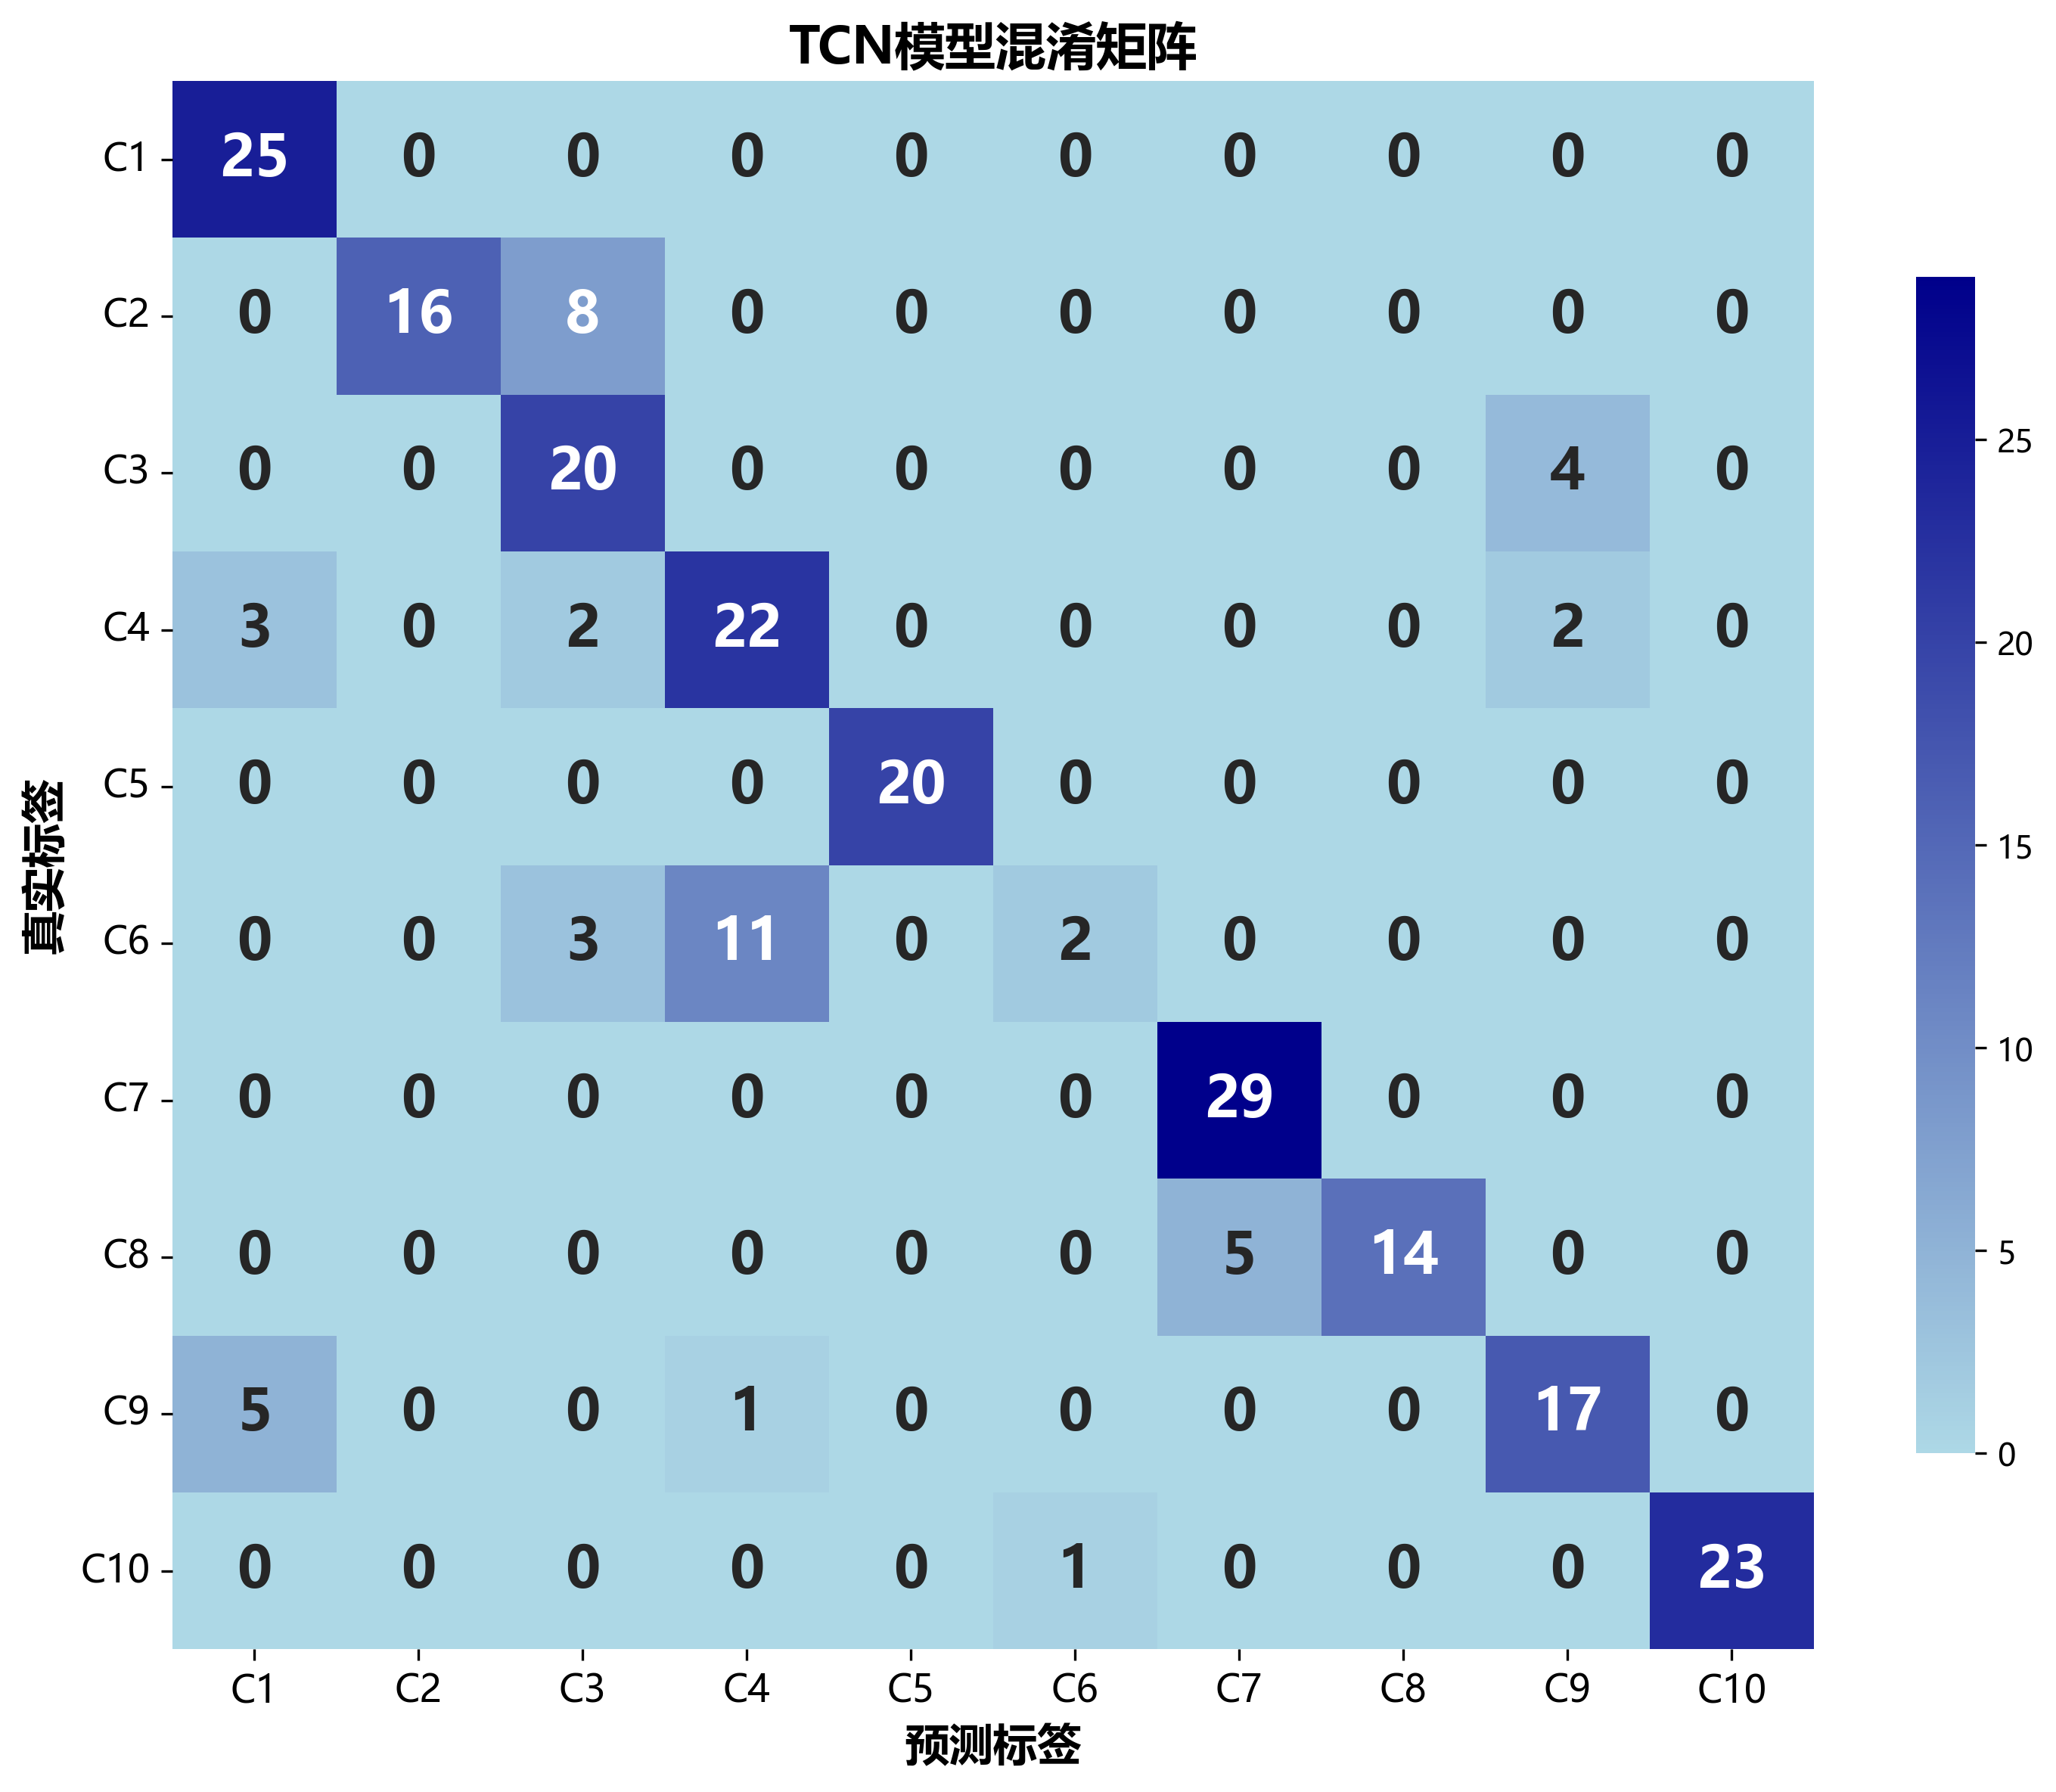

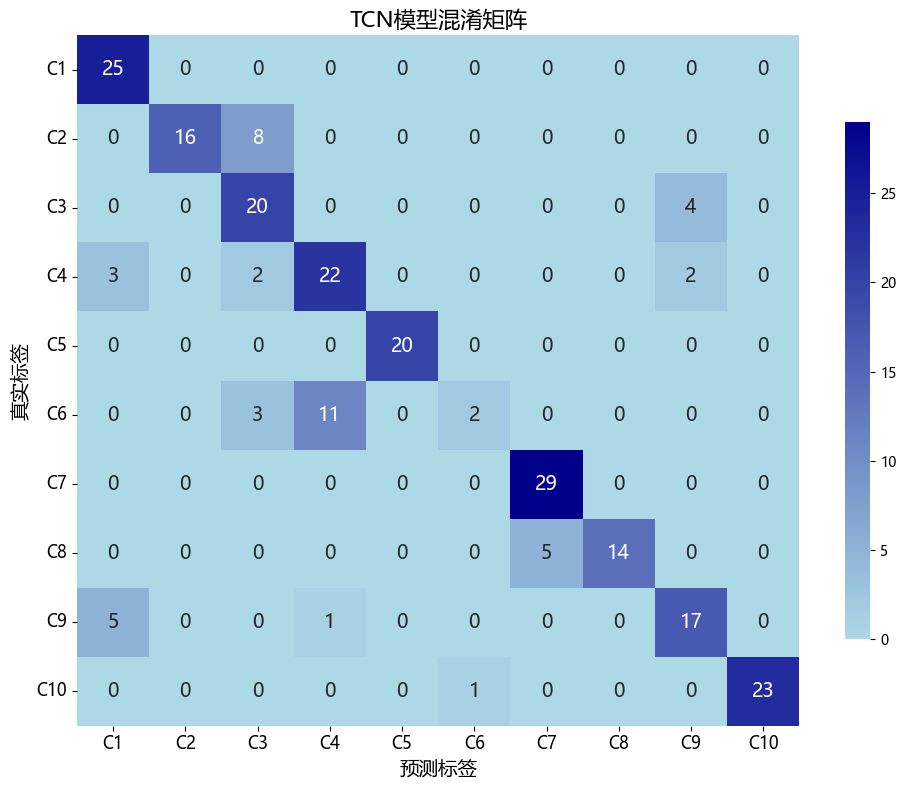

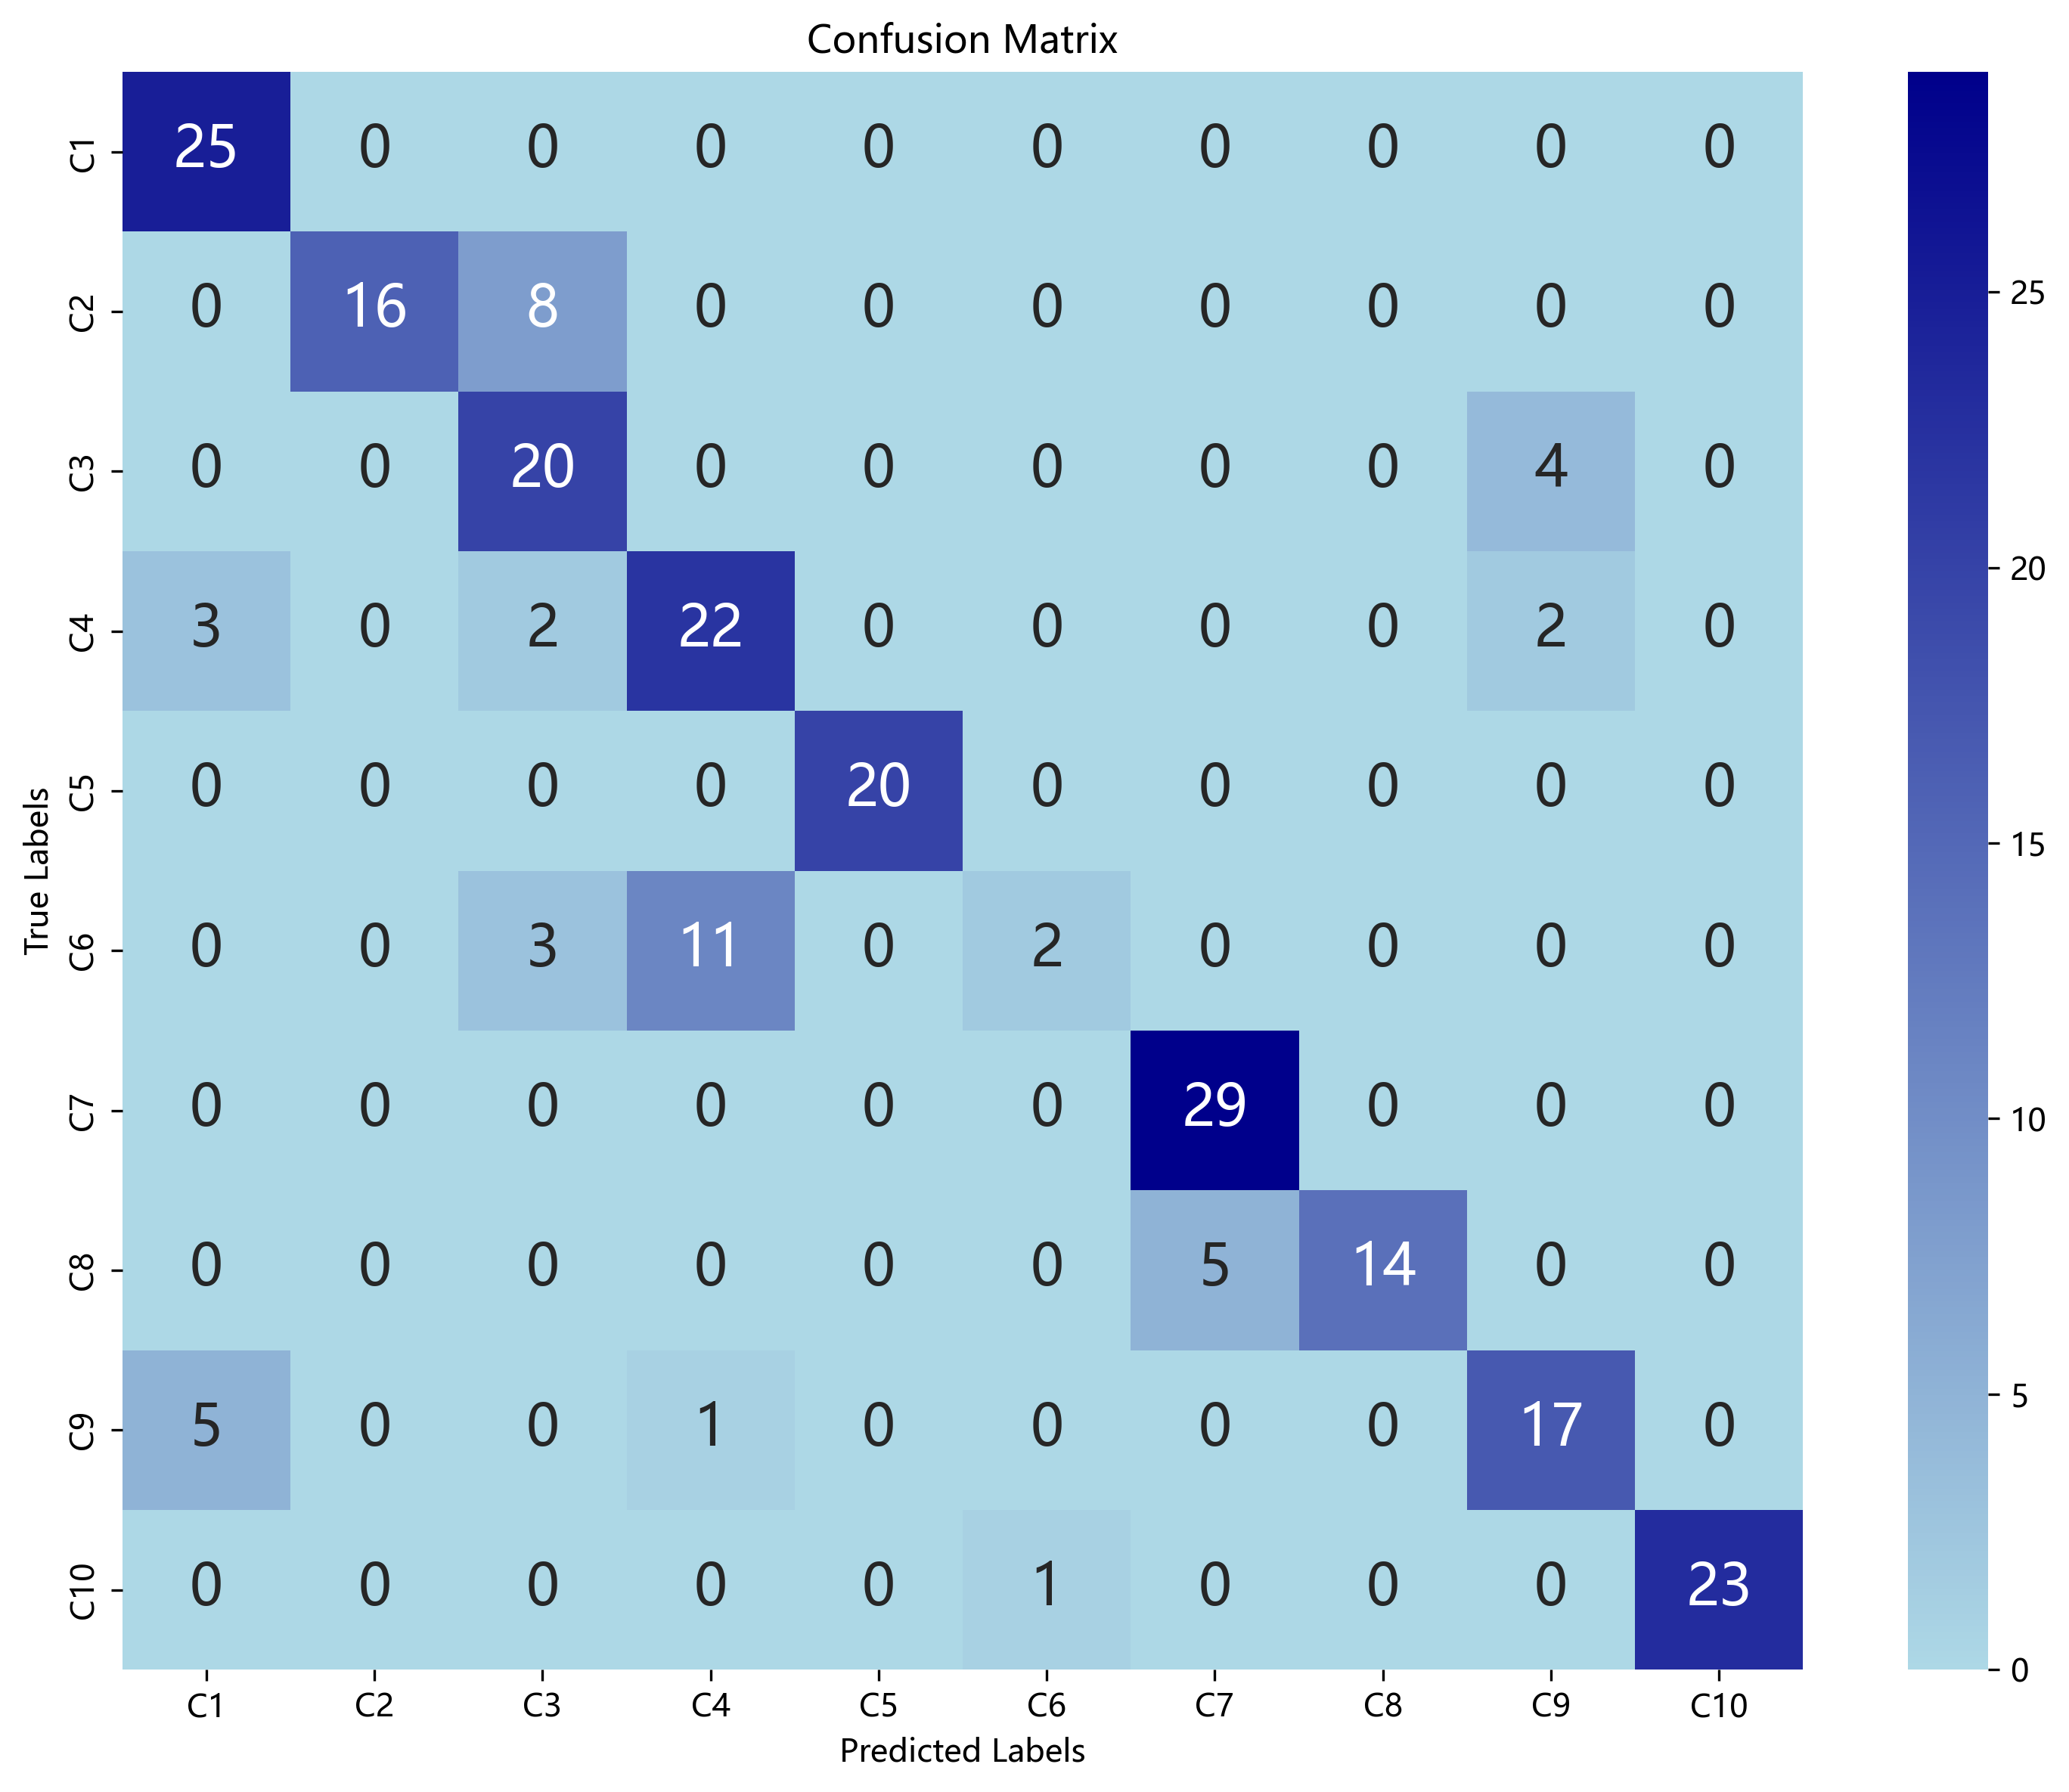

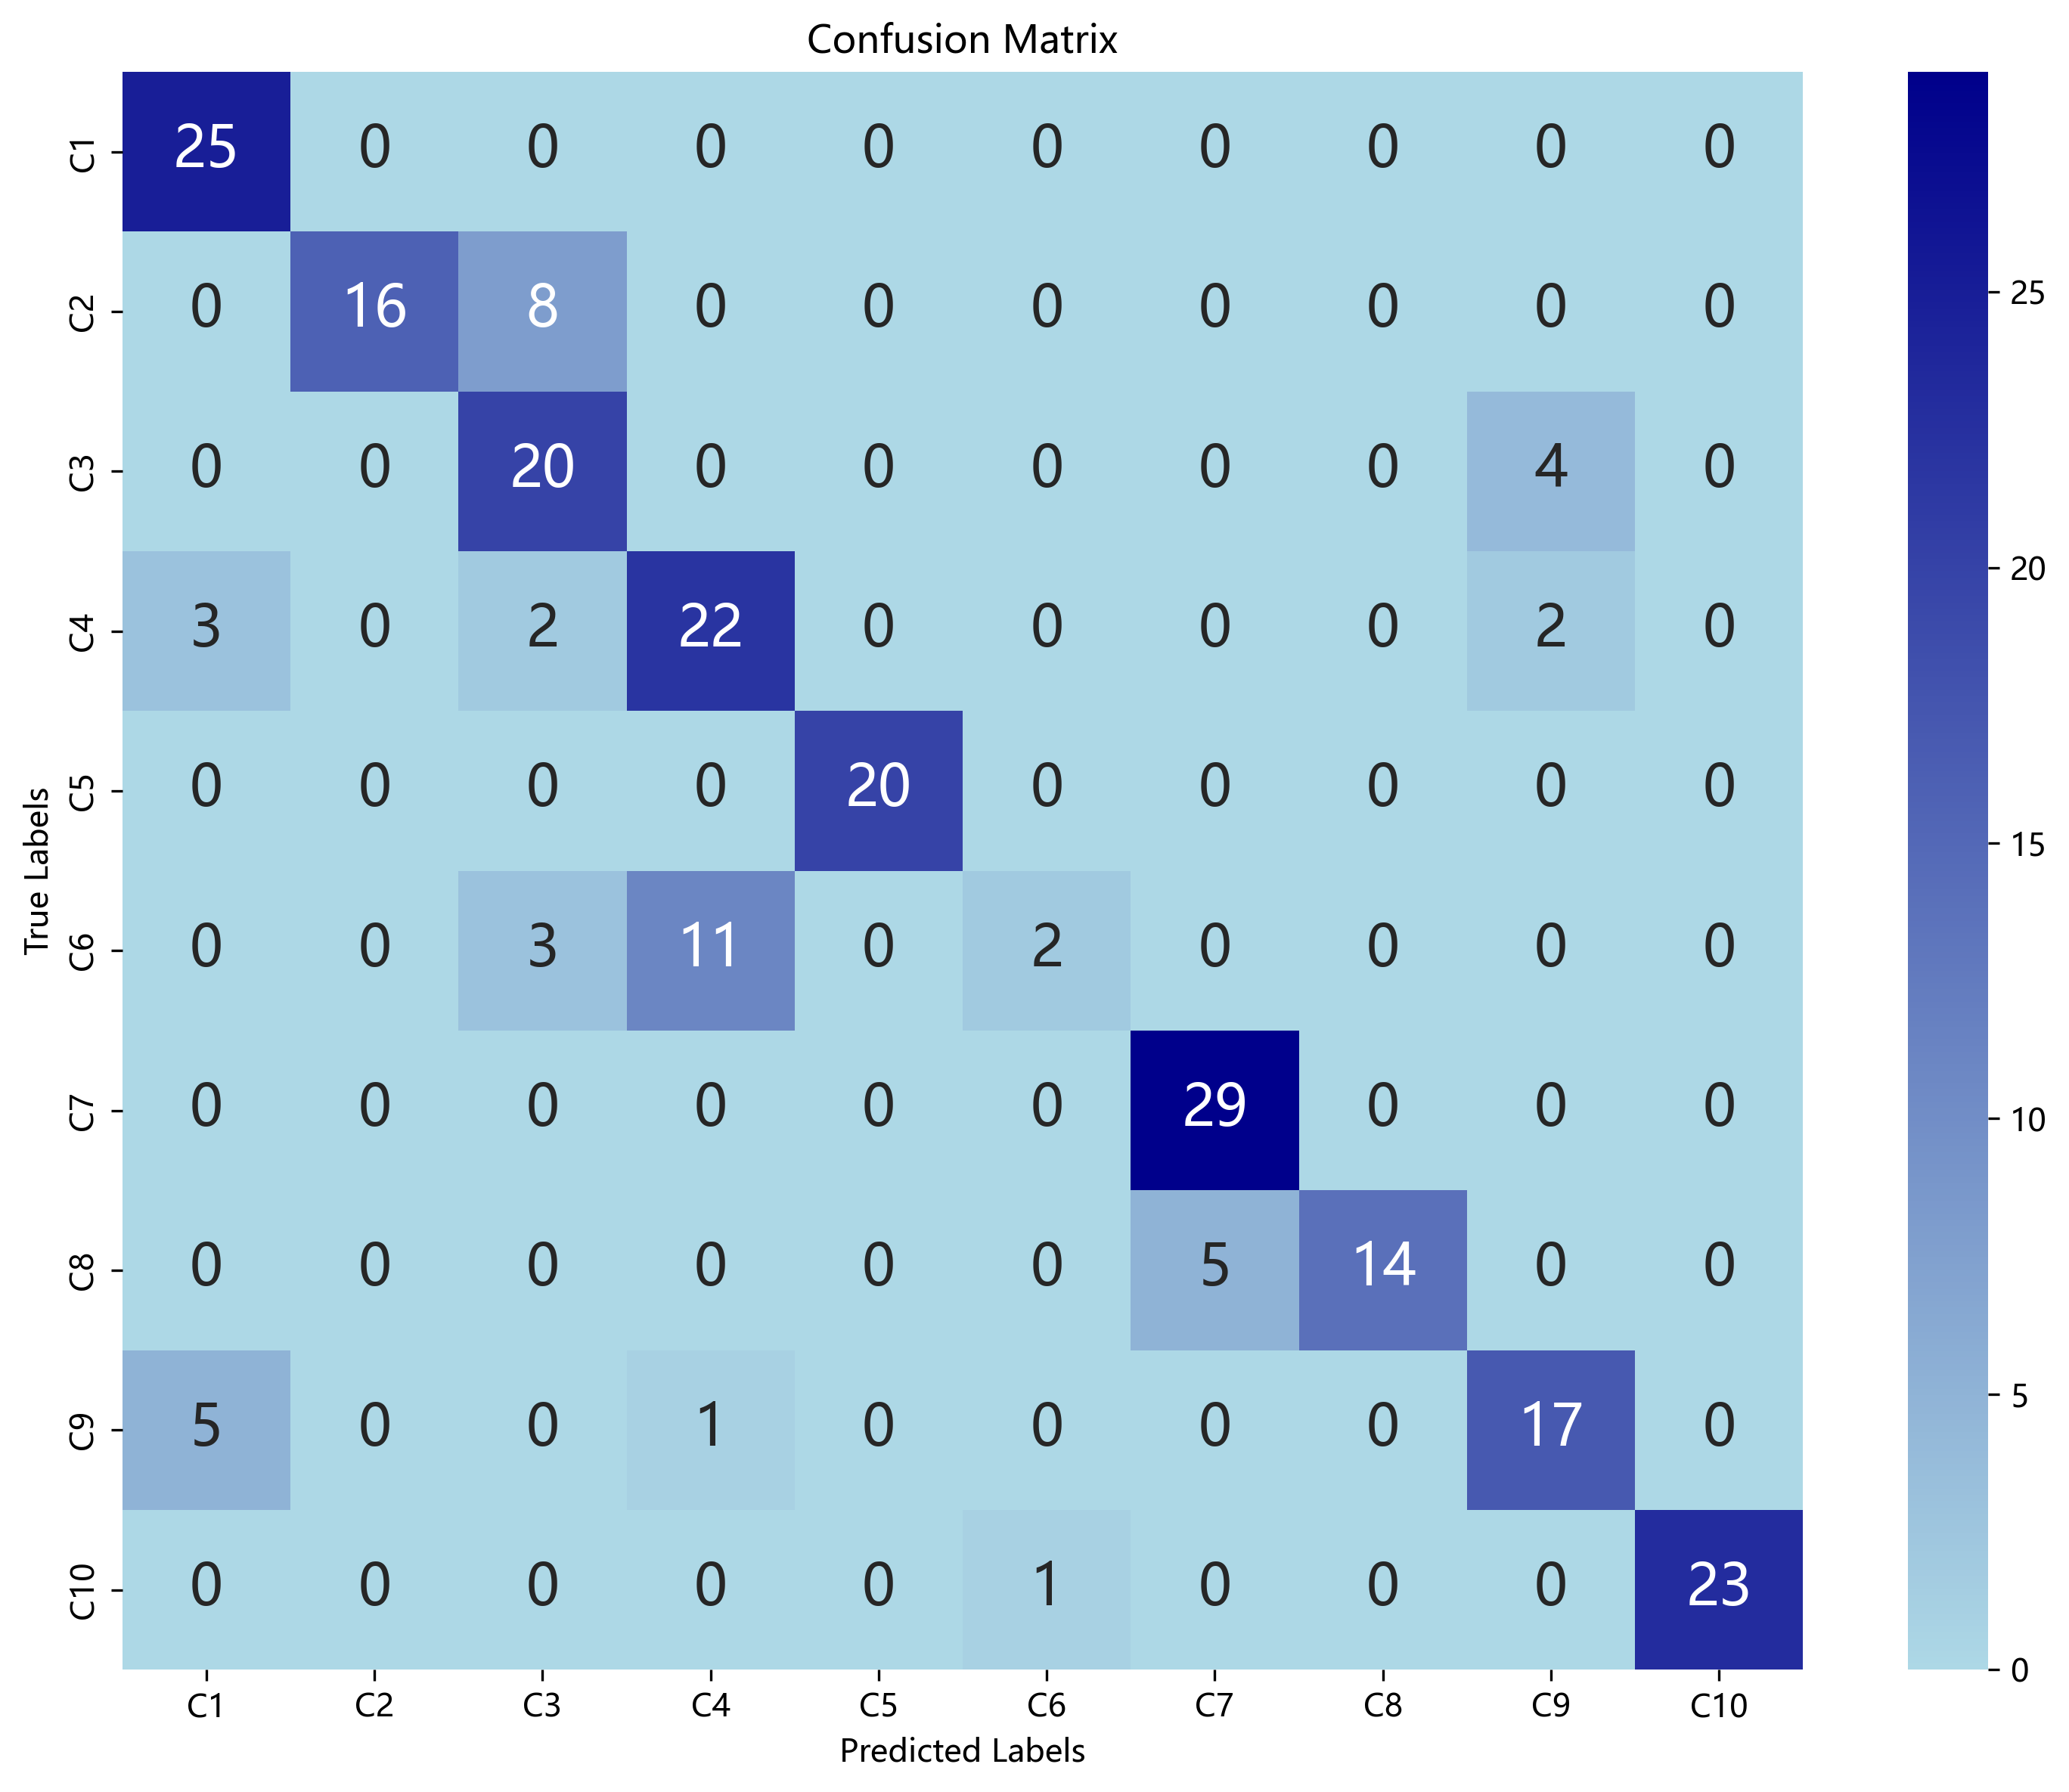

In [13]:
%matplotlib inline 
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 假设你已经定义了 TCN 模型类，并加载了训练好的模型
# 请根据实际情况调整路径和模型参数
model = TCN(input_size=1, output_size=10, num_channels=[64, 128, 256], kernel_size=7, dropout=0.5)
model.load_state_dict(torch.load('best_model_tcn.pt'))  # 加载训练好的模型
model.to('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()

# 加载测试数据（假设 test_loader 已定义）
# 请确保 test_loader 是 DataLoader 类型，且 batch_size 与训练一致
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 生成混淆矩阵
confusion_mat = confusion_matrix(all_labels, all_preds)

# 自定义标签映射
label_mapping = {
    0: "C1", 1: "C2", 2: "C3", 3: "C4", 4: "C5",
    5: "C6", 6: "C7", 7: "C8", 8: "C9", 9: "C10"
}

# 自定义颜色映射：从浅蓝色到深蓝色
colors = ["#ADD8E6", "#00008B"]  # 浅蓝色 (#ADD8E6) 到深蓝色 (#00008B)
cmap = LinearSegmentedColormap.from_list("custom_blues", colors)

# 绘制混淆矩阵
plt.figure(figsize=(10, 8), dpi=300)
sns.heatmap(
    confusion_mat,
    xticklabels=label_mapping.values(),
    yticklabels=label_mapping.values(),
    annot=True,
    annot_kws={'size': 18},
    fmt='d',
    cmap=cmap
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

注意调整参数，
1. 可以适当增加 GCN层数 和每层神经元个数，微调学习率；
2. 增加更多的 epochs,  （注意防止过拟合）